In [1]:
import json

from pathlib import Path
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "NOTEBOOKS":
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_DIR = PROJECT_ROOT / "DATA"
RAW_DIR = DATA_DIR / "RAW"
PROCESSED_DIR = DATA_DIR / "PROCESSED"
MODELS_DIR = PROJECT_ROOT / "MODELS"
OUTPUTS_DIR = PROJECT_ROOT / "OUTPUTS"
PLOTS_DIR = OUTPUTS_DIR / "PLOTS"

for d in [PROCESSED_DIR, MODELS_DIR, PLOTS_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Python:", sys.version)

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score, ConfusionMatrixDisplay
)
import joblib

artifact_path = MODELS_DIR / "predictive_maintenance_model.joblib"
if not artifact_path.exists():
    raise FileNotFoundError("Run 06_training.ipynb first.")

artifact = joblib.load(artifact_path)
model = artifact["model"]
features = artifact["features"]

X_test = pd.read_csv(PROCESSED_DIR / "X_test_selected.csv")[features]
y_test = pd.read_csv(PROCESSED_DIR / "y_test.csv").squeeze("columns").astype(int)

pred = model.predict(X_test)
proba = model.predict_proba(X_test)[:, 1]

metrics = {
    "Accuracy": accuracy_score(y_test, pred),
    "Precision": precision_score(y_test, pred, zero_division=0),
    "Recall": recall_score(y_test, pred, zero_division=0),
    "F1-Score": f1_score(y_test, pred, zero_division=0),
    "ROC-AUC": roc_auc_score(y_test, proba),
}

metrics_df = pd.DataFrame([metrics]).round(4)
display(metrics_df)

metrics_df.to_csv(PROCESSED_DIR / "evaluation_metrics.csv", index=False)

Project root: C:\Users\sitar\Downloads\ASSIGNMENT_CODE\PREDICTIVE-MAINTENANCE
Python: 3.10.19 | packaged by Anaconda, Inc. | (main, Oct 21 2025, 16:41:31) [MSC v.1929 64 bit (AMD64)]


,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,0.975,0.8462,0.3235,0.4681,0.9149


Classification report:
              precision    recall  f1-score   support

           0     0.9767    0.9979    0.9872      1932
           1     0.8462    0.3235    0.4681        68

    accuracy                         0.9750      2000
   macro avg     0.9114    0.6607    0.7276      2000
weighted avg     0.9723    0.9750    0.9695      2000



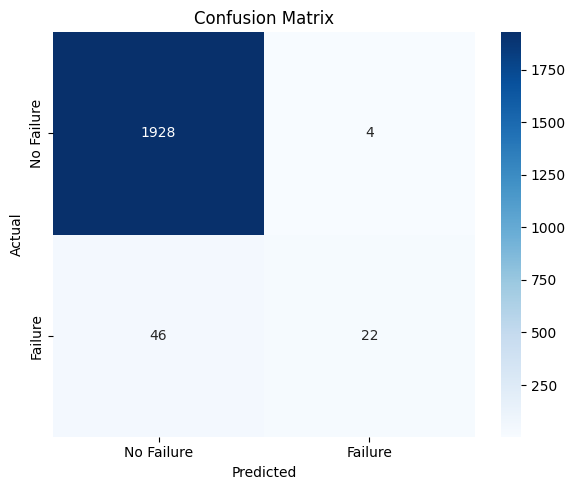

In [2]:
print("Classification report:")
print(classification_report(y_test, pred, digits=4))

cm = confusion_matrix(y_test, pred)
plt.figure(figsize=(6,5))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=["No Failure", "Failure"],
    yticklabels=["No Failure", "Failure"]
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()

In [3]:
# Save a compact evaluation summary for documentation.
summary = {
    "model": "RandomForestClassifier",
    "features": features,
    "metrics": {k: float(v) for k, v in metrics.items()}
}
with open(PROCESSED_DIR / "evaluation_summary.json", "w", encoding="utf-8") as f:
    json.dump(summary, f, indent=2)

print("Evaluation artifacts saved.")
print("\nProject 1 data-science pipeline is documented end-to-end.")

Evaluation artifacts saved.

Project 1 data-science pipeline is documented end-to-end.
